<a href="https://colab.research.google.com/github/jorge-torresgomez/AI_microfluidic/blob/main/code/THz_Protein_Folding/plot_frequencies_motif52_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plot Motif 52 ProDy frequency results from GitHub

This Colab notebook loads your HPC calculation results directly from:

`https://github.com/tkn-tub/bioelectrodynamics/tree/main/code/database/results_motif_52`

It does **plotting only**. It does not install or run ProDy. The required input file is `frequencies_long.csv`; `summary.csv` and `run_manifest.json` are loaded for checking the calculation status.


In [1]:
# Colab setup: standard plotting/data packages only.
# ProDy is NOT required for plotting.

import json
import shutil
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

OUTDIR = Path("plots_motif47_github")
OUTDIR.mkdir(parents=True, exist_ok=True)

print("Ready. Plots will be saved in:", OUTDIR.resolve())


Ready. Plots will be saved in: /content/plots_motif47_github


In [2]:
# GitHub raw URLs for your Motif 47 results.

BASE_URL = "https://raw.githubusercontent.com/tkn-tub/bioelectrodynamics/main/code/database/results_motif_52"

FREQUENCIES_URL = f"{BASE_URL}/frequencies_long.csv"
SUMMARY_URL = f"{BASE_URL}/summary.csv"
MANIFEST_URL = f"{BASE_URL}/run_manifest.json"

print("Frequencies:", FREQUENCIES_URL)
print("Summary:    ", SUMMARY_URL)
print("Manifest:   ", MANIFEST_URL)


Frequencies: https://raw.githubusercontent.com/tkn-tub/bioelectrodynamics/main/code/database/results_motif_52/frequencies_long.csv
Summary:     https://raw.githubusercontent.com/tkn-tub/bioelectrodynamics/main/code/database/results_motif_52/summary.csv
Manifest:    https://raw.githubusercontent.com/tkn-tub/bioelectrodynamics/main/code/database/results_motif_52/run_manifest.json


In [3]:
# Load data from GitHub.

freq = pd.read_csv(FREQUENCIES_URL)
summary = pd.read_csv(SUMMARY_URL)

with urllib.request.urlopen(MANIFEST_URL) as response:
    manifest = json.load(response)

# Ensure numeric columns are numeric.
for col in ["mode_index", "eigenvalue", "frequency_thz"]:
    if col in freq.columns:
        freq[col] = pd.to_numeric(freq[col], errors="coerce")

freq = freq.replace([np.inf, -np.inf], np.nan).dropna(subset=["label", "mode_index", "frequency_thz"])
freq["label"] = freq["label"].astype(str)

print("Frequency table shape:", freq.shape)
print("Labels in frequency table:", sorted(freq["label"].unique()))
print("Number of labels in frequency table:", freq["label"].nunique())
print()
print("Manifest script:", manifest.get("script"))
print("Frequency scale:", manifest.get("frequency_scale"))
print("n_modes_requested:", manifest.get("n_modes_requested"))

summary


Frequency table shape: (32013, 4)
Labels in frequency table: ['1RY2', '2PFF', '3RKU', '4HNW', 'YBR145W', 'YGL001C', 'YGR177C', 'YLR174W', 'YNR057C', 'YPL061W']
Number of labels in frequency table: 10

Manifest script: compute_prody_frequencies_Motif_52_selectable.py
Frequency scale: 0.225
n_modes_requested: all


,label,source_type,source_file,n_calpha,n_modes,min_frequency_thz,max_frequency_thz,mean_frequency_thz,modes_microwave_lt_0_1_thz,modes_thz_0_1_to_3_0_thz,modes_beyond_3_0_thz,negative_eigenvalues_clipped,elapsed_seconds,status,error
0,1RY2,RCSB,structures/1RY2.pdb,615,1839,0.140551,1.559508,0.975663,0,1839,0,0,34.665,ok,NaN
1,2PFF,RCSB,structures/2PFF.pdb,5661,16941,0.009724,1.643471,0.908503,75,16866,0,0,974.487,ok,NaN
2,4HNW,RCSB,structures/4HNW.pdb,971,2907,0.035809,1.524728,0.910854,9,2898,0,0,125.124,ok,NaN
3,3RKU,RCSB,structures/3RKU.pdb,1072,3210,0.125349,1.598483,1.014495,0,3210,0,0,129.476,ok,NaN
4,YPL061W,AlphaFold/GitHub,structures/AF-P54115-F1-model_v6.pdb,500,1494,0.027783,1.563966,0.980289,3,1491,0,0,50.382,ok,NaN
5,YBR145W,AlphaFold/GitHub,structures/AF-P38113-F1-model_v6.pdb,351,1047,0.141366,1.568515,0.953362,0,1047,0,0,24.888,ok,NaN
6,YGR177C,AlphaFold/GitHub,structures/AF-P53296-F1-model_v6.pdb,535,1599,0.151369,1.528379,0.942445,0,1599,0,0,56.972,ok,NaN
7,YGL001C,AlphaFold/GitHub,structures/AF-P53199-F1-model_v6.pdb,349,1041,0.092554,1.537476,0.927434,1,1040,0,0,35.799,ok,NaN
8,YLR174W,AlphaFold/GitHub,structures/AF-P41939-F1-model_v6.pdb,412,1230,0.035334,1.545221,0.898389,5,1225,0,0,36.230,ok,NaN
9,YNR057C,AlphaFold/GitHub,structures/AF-P53630-F1-model_v6.pdb,237,705,0.018906,1.480102,0.896434,7,698,0,0,16.216,ok,NaN


In [5]:
# Basic statistics calculated directly from frequencies_long.csv.

stats = (
    freq.groupby("label")["frequency_thz"]
    .agg(n_modes="count", min_thz="min", max_thz="max", mean_thz="mean", median_thz="median", std_thz="std")
    .reset_index()
)

stats_path = OUTDIR / "statistics_from_frequencies.csv"
stats.to_csv(stats_path, index=False)

print("Saved:", stats_path)
stats


Saved: plots_motif47_github/statistics_from_frequencies.csv


,label,n_modes,min_thz,max_thz,mean_thz,median_thz,std_thz
0,1RY2,1839,0.140551,1.559508,0.975663,0.980334,0.228803
1,2PFF,16941,0.009724,1.643471,0.908503,0.925056,0.264647
2,3RKU,3210,0.125349,1.598483,1.014495,1.034487,0.235689
3,4HNW,2907,0.035809,1.524728,0.910854,0.929915,0.247118
4,YBR145W,1047,0.141366,1.568515,0.953362,0.966300,0.241859
5,YGL001C,1041,0.092554,1.537476,0.927434,0.938624,0.237124
6,YGR177C,1599,0.151369,1.528379,0.942445,0.950855,0.236663
7,YLR174W,1230,0.035334,1.545221,0.898389,0.921083,0.260420
8,YNR057C,705,0.018906,1.480102,0.896434,0.914441,0.247408
9,YPL061W,1494,0.027783,1.563966,0.980289,0.990387,0.241698


In [6]:
# Helper function for saving and displaying plots.

def save_and_show(filename: str, dpi: int = 300):
    path = OUTDIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("Saved:", path)
    plt.show()


Saved: plots_motif47_github/vdos_overlay_full_range.png


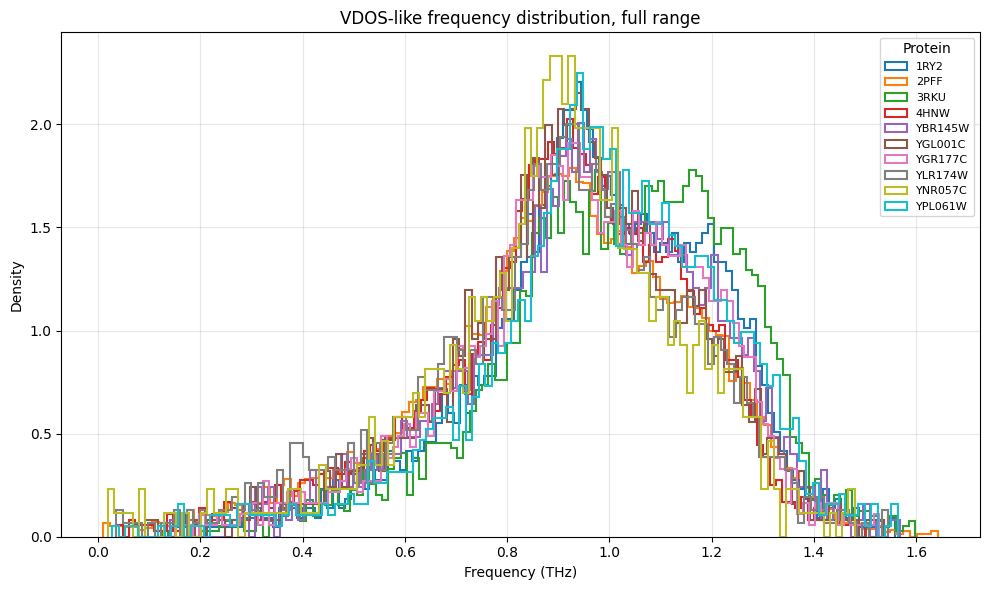

In [7]:
# Plot 1: overlay histogram / VDOS-like distribution, full frequency range.

plt.figure(figsize=(10, 6))

for label, group in freq.groupby("label"):
    values = group["frequency_thz"].dropna().to_numpy()
    plt.hist(values, bins=120, density=True, histtype="step", linewidth=1.5, label=label)

plt.xlabel("Frequency (THz)")
plt.ylabel("Density")
plt.title("VDOS-like frequency distribution, full range")
plt.legend(title="Protein", fontsize=8)
plt.grid(True, alpha=0.3)
save_and_show("vdos_overlay_full_range.png")


Saved: plots_motif47_github/vdos_overlay_0_to_3_THz.png


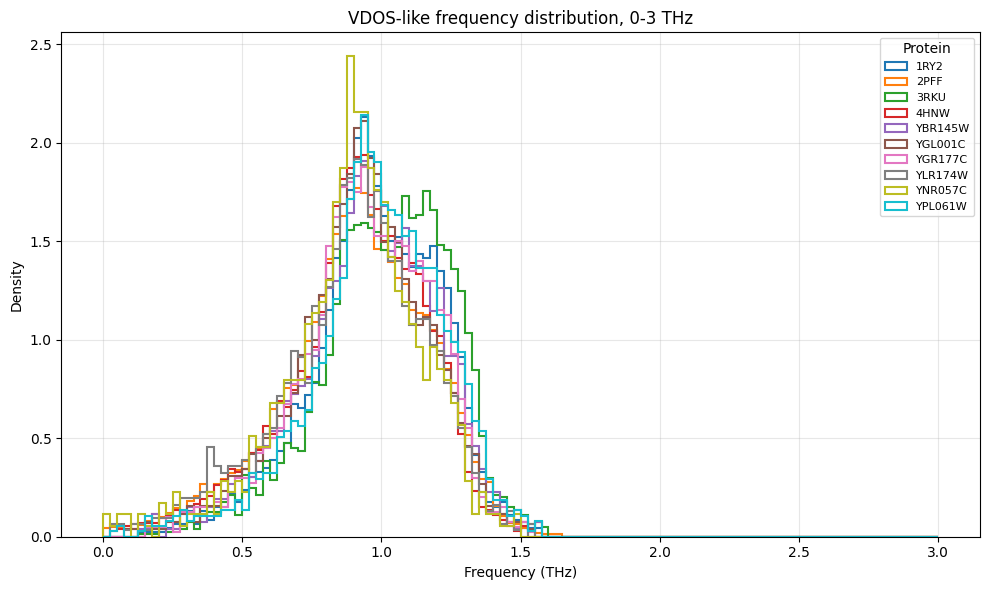

In [8]:
# Plot 2: overlay histogram / VDOS-like distribution, zoomed to 0-3 THz.

ZOOM_MIN = 0.0
ZOOM_MAX = 3.0

plt.figure(figsize=(10, 6))

for label, group in freq.groupby("label"):
    values = group["frequency_thz"].dropna().to_numpy()
    values = values[(values >= ZOOM_MIN) & (values <= ZOOM_MAX)]
    if len(values) > 0:
        plt.hist(values, bins=120, range=(ZOOM_MIN, ZOOM_MAX), density=True, histtype="step", linewidth=1.5, label=label)

plt.xlabel("Frequency (THz)")
plt.ylabel("Density")
plt.title(f"VDOS-like frequency distribution, {ZOOM_MIN:g}-{ZOOM_MAX:g} THz")
plt.legend(title="Protein", fontsize=8)
plt.grid(True, alpha=0.3)
save_and_show("vdos_overlay_0_to_3_THz.png")


Saved: plots_motif47_github/frequency_vs_mode_index.png


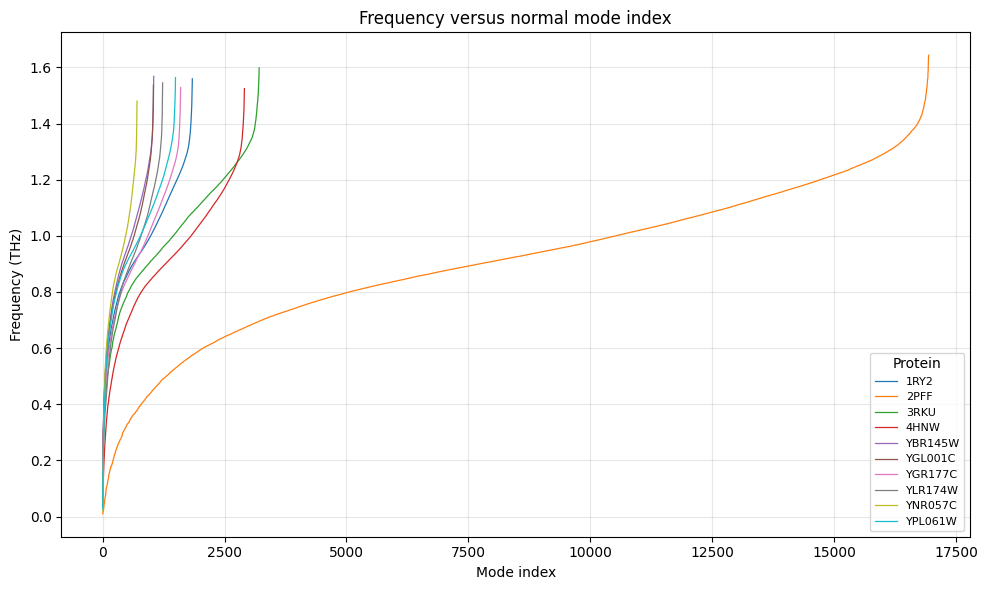

In [9]:
# Plot 3: frequency versus mode index.

plt.figure(figsize=(10, 6))

for label, group in freq.groupby("label"):
    group = group.sort_values("mode_index")
    plt.plot(group["mode_index"], group["frequency_thz"], linewidth=0.9, label=label)

plt.xlabel("Mode index")
plt.ylabel("Frequency (THz)")
plt.title("Frequency versus normal mode index")
plt.legend(title="Protein", fontsize=8)
plt.grid(True, alpha=0.3)
save_and_show("frequency_vs_mode_index.png")


/tmp/ipykernel_1273/2152999472.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


Saved: plots_motif47_github/boxplot_full_range.png


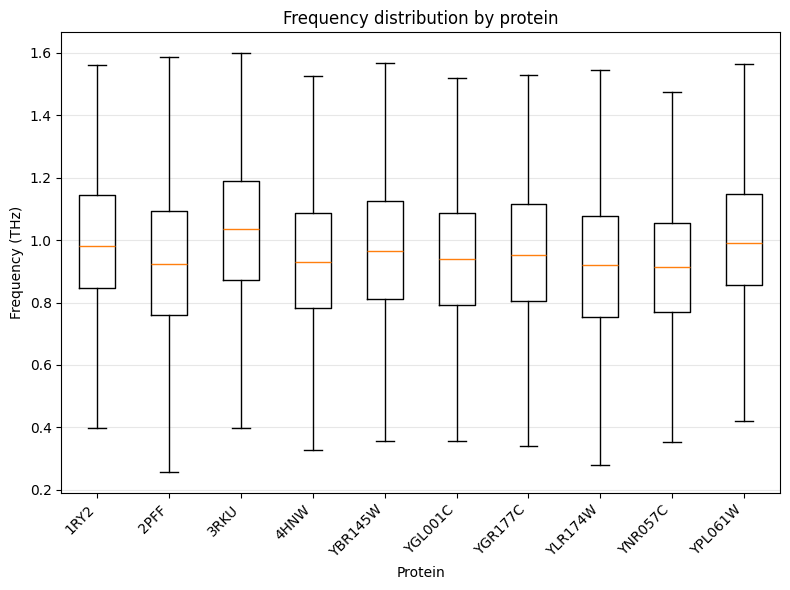

In [10]:
# Plot 4: boxplot of frequency distributions.

labels = sorted(freq["label"].unique())
data = [freq.loc[freq["label"] == label, "frequency_thz"].dropna().to_numpy() for label in labels]

plt.figure(figsize=(max(8, len(labels) * 0.8), 6))
plt.boxplot(data, labels=labels, showfliers=False)
plt.xlabel("Protein")
plt.ylabel("Frequency (THz)")
plt.title("Frequency distribution by protein")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
save_and_show("boxplot_full_range.png")


In [ ]:
# Plot 5: boxplot zoomed to 0-3 THz.

zoomed = freq[(freq["frequency_thz"] >= 0.0) & (freq["frequency_thz"] <= 3.0)].copy()
labels_zoom = sorted(zoomed["label"].unique())
data_zoom = [zoomed.loc[zoomed["label"] == label, "frequency_thz"].dropna().to_numpy() for label in labels_zoom]

plt.figure(figsize=(max(8, len(labels_zoom) * 0.8), 6))
plt.boxplot(data_zoom, labels=labels_zoom, showfliers=False)
plt.xlabel("Protein")
plt.ylabel("Frequency (THz)")
plt.title("Frequency distribution by protein, 0-3 THz")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
save_and_show("boxplot_0_to_3_THz.png")


In [ ]:
# Plot 6: mean frequency by protein.

plot_stats = stats.sort_values("mean_thz")

plt.figure(figsize=(max(8, len(plot_stats) * 0.8), 6))
plt.bar(plot_stats["label"], plot_stats["mean_thz"])
plt.xlabel("Protein")
plt.ylabel("Mean frequency (THz)")
plt.title("Mean frequency by protein")
plt.xticks(rotation=45, ha="right")
plt.grid(True, axis="y", alpha=0.3)
save_and_show("mean_frequency_by_protein.png")


In [ ]:
# Plot 7: count of modes by frequency range.

range_labels = ["<0.1 THz", "0.1-3.0 THz", ">3.0 THz"]
range_bins = [-np.inf, 0.1, 3.0, np.inf]

freq_ranges = freq.copy()
freq_ranges["frequency_range"] = pd.cut(
    freq_ranges["frequency_thz"],
    bins=range_bins,
    labels=range_labels,
    include_lowest=True,
)

counts = (
    freq_ranges.groupby(["label", "frequency_range"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range_labels, fill_value=0)
)

counts_path = OUTDIR / "mode_counts_by_frequency_range.csv"
counts.to_csv(counts_path)
print("Saved:", counts_path)
display(counts)

ax = counts.plot(kind="bar", figsize=(max(8, len(counts) * 0.8), 6))
ax.set_xlabel("Protein")
ax.set_ylabel("Number of modes")
ax.set_title("Mode counts by frequency range")
ax.grid(True, axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Range")
save_and_show("mode_counts_by_frequency_range.png")


In [ ]:
# Plot 8: individual histogram for each protein.

hist_dir = OUTDIR / "individual_histograms"
hist_dir.mkdir(parents=True, exist_ok=True)

for label, group in freq.groupby("label"):
    values = group["frequency_thz"].dropna().to_numpy()

    plt.figure(figsize=(8, 5))
    plt.hist(values, bins=120, density=True, histtype="stepfilled", alpha=0.5)
    plt.xlabel("Frequency (THz)")
    plt.ylabel("Density")
    plt.title(f"Frequency distribution: {label}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    path = hist_dir / f"histogram_{label}.png"
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)
    plt.show()


In [ ]:
# Save all plots/tables into one ZIP file and download it from Colab.

zip_base = "plots_motif47_github"
zip_path = shutil.make_archive(zip_base, "zip", OUTDIR)
print("Created:", zip_path)

try:
    from google.colab import files
    files.download(zip_path)
except Exception as exc:
    print("Automatic Colab download was not available:", exc)
    print("You can manually download the ZIP from the Colab file browser:", zip_path)


## Note about incomplete calculations

If the `summary.csv` table shows failed structures, rerun the HPC calculation after making sure all structure files exist in the `structures/` folder, or run the compute script without `--no-download` so it can download missing structures before calculation.
